# Inference Comparison: 20-Epoch vs 60-Epoch Weights

Comparing detection outputs from two YOLO runs on the **same video**:
- **run2** → best weights from 20 epochs
- **run6** → best weights from 60 epochs

Both runs used the same confidence threshold (0.25), IoU threshold (0.45), and input size (640).

## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import defaultdict

## Paths & Class Names

In [2]:
RUN2_LABELS = Path(r"C:\Users\samar\OneDrive\Desktop\Grad Project\Code\tamakkan_inference_results\run2\labels")
RUN6_LABELS = Path(r"C:\Users\samar\OneDrive\Desktop\Grad Project\Code\tamakkan_inference_results\run6\labels")

# BDD100K class names (YOLO class IDs 0-9)
CLASS_NAMES = {
    0: "pedestrian",
    1: "rider",
    2: "car",
    3: "truck",
    4: "bus",
    5: "train",
    6: "motorcycle",
    7: "bicycle",
    8: "traffic light",
    9: "traffic sign"
}

## Load Label Files

In [3]:
def load_labels(labels_dir):
    """
    Reads all .txt label files in a directory.
    Each line format: class_id x_center y_center width height confidence
    Returns a DataFrame with columns: frame, class_id, x, y, w, h, conf
    """
    records = []
    for txt_file in sorted(Path(labels_dir).glob("*.txt")):
        frame_name = txt_file.stem
        with open(txt_file, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 6:
                    cls, x, y, w, h, conf = parts
                    records.append({
                        "frame": frame_name,
                        "class_id": int(cls),
                        "class_name": CLASS_NAMES.get(int(cls), f"cls_{cls}"),
                        "x": float(x),
                        "y": float(y),
                        "w": float(w),
                        "h": float(h),
                        "conf": float(conf),
                    })
    return pd.DataFrame(records)

df_run2 = load_labels(RUN2_LABELS)
df_run6 = load_labels(RUN6_LABELS)

print(f"run2 (20 epochs): {len(df_run2):,} total detections across {df_run2['frame'].nunique()} frames")
print(f"run6 (60 epochs): {len(df_run6):,} total detections across {df_run6['frame'].nunique()} frames")

run2 (20 epochs): 23,044 total detections across 1500 frames
run6 (60 epochs): 20,839 total detections across 1500 frames


## 1. Summary Statistics

In [4]:
def summary(df, label):
    per_frame = df.groupby("frame").size()
    print(f"\n{'='*40}")
    print(f"  {label}")
    print(f"{'='*40}")
    print(f"  Total detections      : {len(df):,}")
    print(f"  Frames with detections: {df['frame'].nunique()}")
    print(f"  Avg detections/frame  : {per_frame.mean():.2f}")
    print(f"  Max detections/frame  : {per_frame.max()}")
    print(f"  Min detections/frame  : {per_frame.min()}")
    print(f"  Mean confidence       : {df['conf'].mean():.4f}")
    print(f"  Median confidence     : {df['conf'].median():.4f}")
    print(f"  Std confidence        : {df['conf'].std():.4f}")

summary(df_run2, "run2 — 20-epoch weights")
summary(df_run6, "run6 — 60-epoch weights")


  run2 — 20-epoch weights
  Total detections      : 23,044
  Frames with detections: 1500
  Avg detections/frame  : 15.36
  Max detections/frame  : 29
  Min detections/frame  : 7
  Mean confidence       : 0.4998
  Median confidence     : 0.4608
  Std confidence        : 0.1864

  run6 — 60-epoch weights
  Total detections      : 20,839
  Frames with detections: 1500
  Avg detections/frame  : 13.89
  Max detections/frame  : 26
  Min detections/frame  : 6
  Mean confidence       : 0.5161
  Median confidence     : 0.4760
  Std confidence        : 0.1926


## 2. Detections Per Frame Over Time

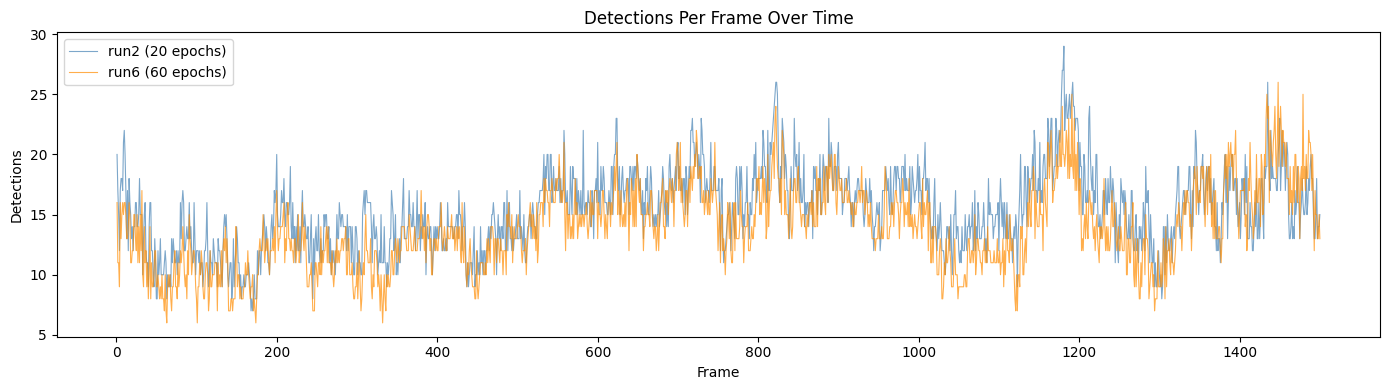

In [5]:
def detections_per_frame(df):
    counts = df.groupby("frame").size().reset_index(name="count")
    # Sort by frame number extracted from name
    counts["frame_num"] = counts["frame"].str.extract(r'_(\d+)$').astype(int)
    return counts.sort_values("frame_num").reset_index(drop=True)

dpf2 = detections_per_frame(df_run2)
dpf6 = detections_per_frame(df_run6)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dpf2["frame_num"], dpf2["count"], alpha=0.7, linewidth=0.8, label="run2 (20 epochs)", color="steelblue")
ax.plot(dpf6["frame_num"], dpf6["count"], alpha=0.7, linewidth=0.8, label="run6 (60 epochs)", color="darkorange")
ax.set_xlabel("Frame")
ax.set_ylabel("Detections")
ax.set_title("Detections Per Frame Over Time")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Confidence Score Distribution

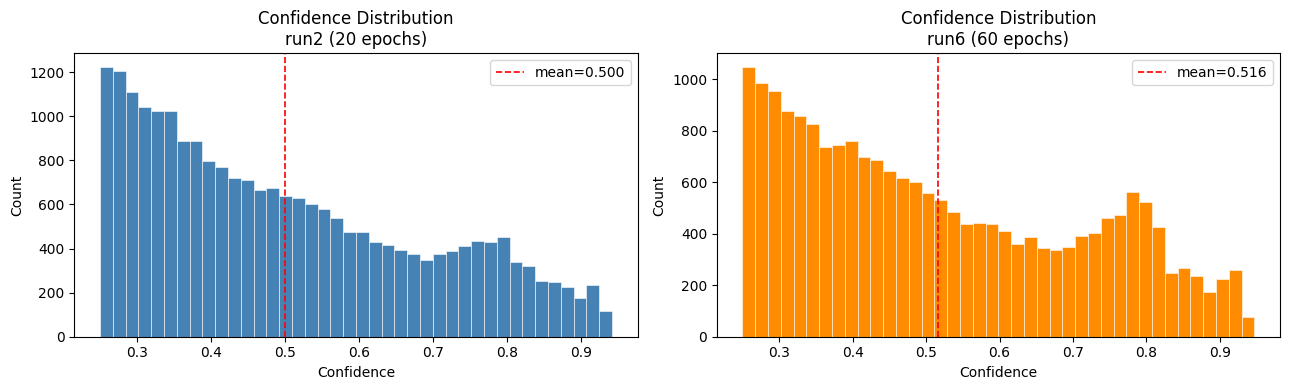

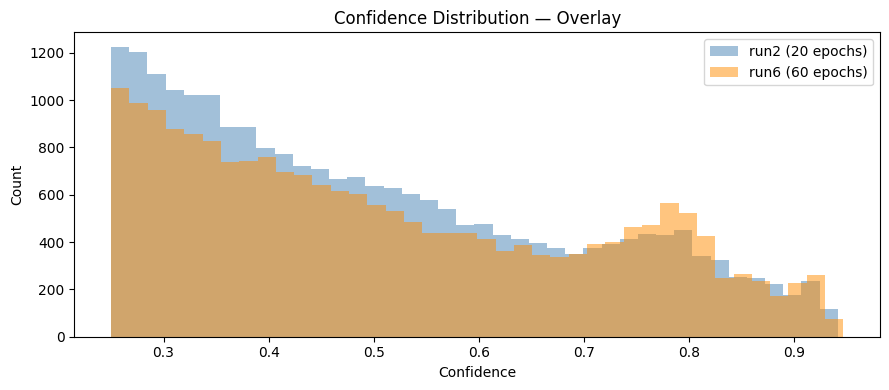

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, df, label, color in zip(
    axes,
    [df_run2, df_run6],
    ["run2 (20 epochs)", "run6 (60 epochs)"],
    ["steelblue", "darkorange"]
):
    ax.hist(df["conf"], bins=40, color=color, edgecolor="white", linewidth=0.4)
    ax.axvline(df["conf"].mean(), color="red", linestyle="--", linewidth=1.2, label=f"mean={df['conf'].mean():.3f}")
    ax.set_title(f"Confidence Distribution\n{label}")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.show()

# Overlay comparison
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_run2["conf"], bins=40, alpha=0.5, color="steelblue", label="run2 (20 epochs)")
ax.hist(df_run6["conf"], bins=40, alpha=0.5, color="darkorange", label="run6 (60 epochs)")
ax.set_xlabel("Confidence")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution — Overlay")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Class Distribution

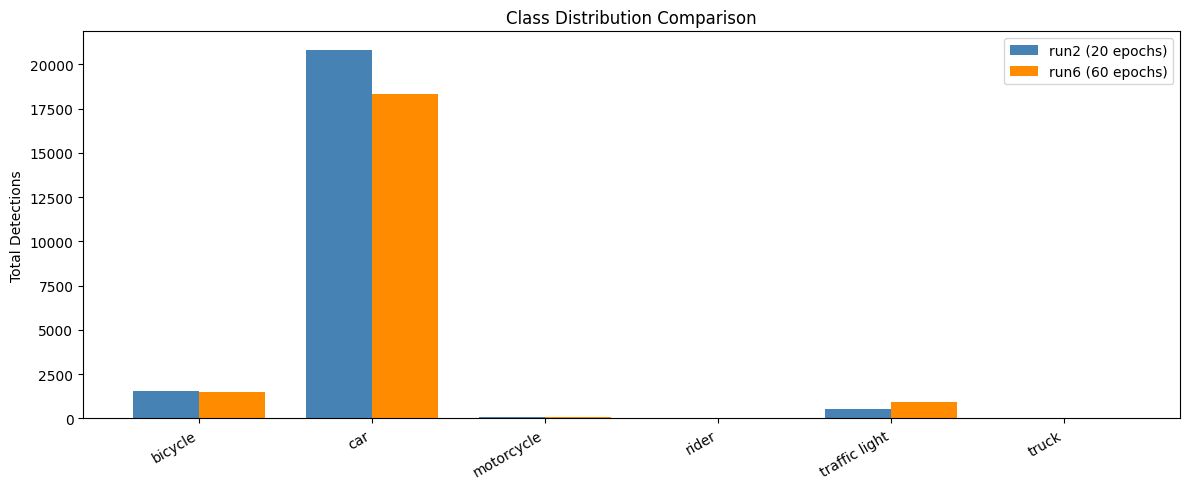

In [7]:
all_classes = sorted(set(df_run2["class_name"].unique()) | set(df_run6["class_name"].unique()))

counts2 = df_run2["class_name"].value_counts().reindex(all_classes, fill_value=0)
counts6 = df_run6["class_name"].value_counts().reindex(all_classes, fill_value=0)

x = np.arange(len(all_classes))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
bars2 = ax.bar(x - width/2, counts2.values, width, label="run2 (20 epochs)", color="steelblue")
bars6 = ax.bar(x + width/2, counts6.values, width, label="run6 (60 epochs)", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(all_classes, rotation=30, ha="right")
ax.set_ylabel("Total Detections")
ax.set_title("Class Distribution Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Per-Class Mean Confidence

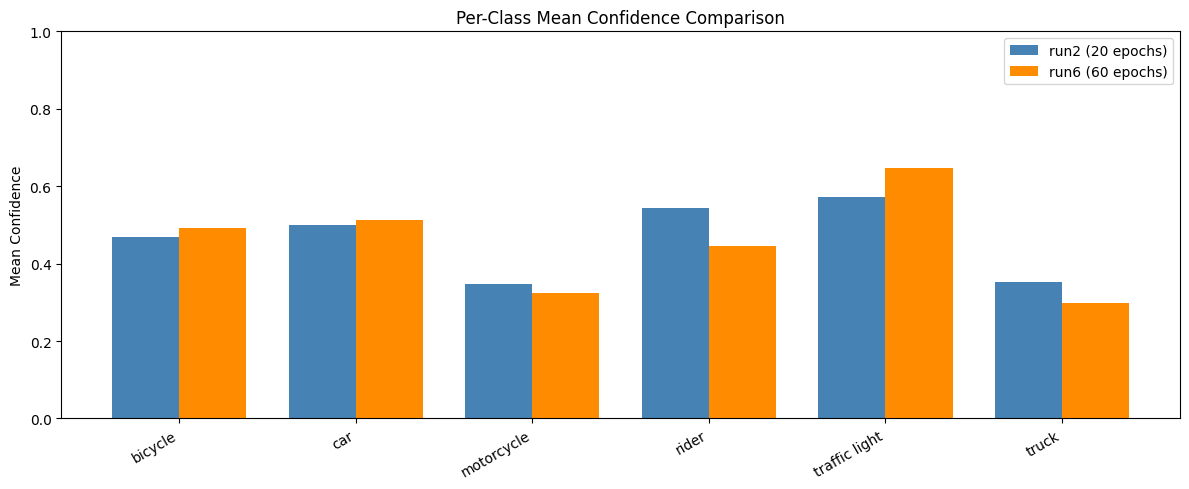

In [8]:
mean_conf2 = df_run2.groupby("class_name")["conf"].mean().reindex(all_classes)
mean_conf6 = df_run6.groupby("class_name")["conf"].mean().reindex(all_classes)

x = np.arange(len(all_classes))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, mean_conf2.values, width, label="run2 (20 epochs)", color="steelblue")
ax.bar(x + width/2, mean_conf6.values, width, label="run6 (60 epochs)", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(all_classes, rotation=30, ha="right")
ax.set_ylabel("Mean Confidence")
ax.set_ylim(0, 1)
ax.set_title("Per-Class Mean Confidence Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Frames With Zero Detections

In [9]:
all_frames = set(dpf2["frame_num"]) | set(dpf6["frame_num"])

frames2 = set(dpf2["frame_num"])
frames6 = set(dpf6["frame_num"])

missing2 = all_frames - frames2
missing6 = all_frames - frames6

print(f"Frames with zero detections:")
print(f"  run2 (20 epochs): {len(missing2)} frames")
print(f"  run6 (60 epochs): {len(missing6)} frames")

Frames with zero detections:
  run2 (20 epochs): 0 frames
  run6 (60 epochs): 0 frames


## 7. Side-by-Side Summary Table

In [10]:
per_frame2 = df_run2.groupby("frame").size()
per_frame6 = df_run6.groupby("frame").size()

summary_data = {
    "Metric": [
        "Total detections",
        "Avg detections / frame",
        "Max detections / frame",
        "Min detections / frame",
        "Frames with 0 detections",
        "Mean confidence",
        "Median confidence",
        "Std confidence",
        "High-conf detections (≥0.7)",
        "Low-conf detections (<0.35)",
    ],
    "run2 (20 epochs)": [
        len(df_run2),
        f"{per_frame2.mean():.2f}",
        per_frame2.max(),
        per_frame2.min(),
        len(missing2),
        f"{df_run2['conf'].mean():.4f}",
        f"{df_run2['conf'].median():.4f}",
        f"{df_run2['conf'].std():.4f}",
        len(df_run2[df_run2['conf'] >= 0.7]),
        len(df_run2[df_run2['conf'] < 0.35]),
    ],
    "run6 (60 epochs)": [
        len(df_run6),
        f"{per_frame6.mean():.2f}",
        per_frame6.max(),
        per_frame6.min(),
        len(missing6),
        f"{df_run6['conf'].mean():.4f}",
        f"{df_run6['conf'].median():.4f}",
        f"{df_run6['conf'].std():.4f}",
        len(df_run6[df_run6['conf'] >= 0.7]),
        len(df_run6[df_run6['conf'] < 0.35]),
    ],
}

summary_df = pd.DataFrame(summary_data)
summary_df

,Metric,run2 (20 epochs),run6 (60 epochs)
0,Total detections,23044,20839
1,Avg detections / frame,15.36,13.89
2,Max detections / frame,29,26
3,Min detections / frame,7,6
4,Frames with 0 detections,0,0
5,Mean confidence,0.4998,0.5161
6,Median confidence,0.4608,0.4760
7,Std confidence,0.1864,0.1926
8,High-conf detections (≥0.7),4393,4791
9,Low-conf detections (<0.35),6415,5329


Why run6 is Better
1. More confident, less noisy
run6 has 1,086 fewer low-confidence detections these are the weak, uncertain boxes that are likely false positives. At the same time it has 398 more high-confidence detections. The 60-epoch model learned to be more selective.

2. Traffic light detection improved dramatically

3. Better bicycle confidence
Avg conf went from 0.4682 → 0.4923. Small but consistent improvement.